# Bias-Variance Trade-off in Machine Learning

This notebook explores the **bias-variance trade-off** using a case study in **computational biology**. We simulate a dataset to predict gene expression from epigenetic signals and apply polynomial regression with and without regularization to demonstrate generalization.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

sns.set(style='whitegrid')
np.random.seed(42)

# Simulate gene expression data
n = 200
X = np.random.uniform(0, 10, n).reshape(-1, 1)
true_function = lambda x: 2 * np.sin(x) + 0.3 * x
noise = np.random.normal(0, 1.5, n)
y = true_function(X).ravel() + noise
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## True Function vs Noisy Data

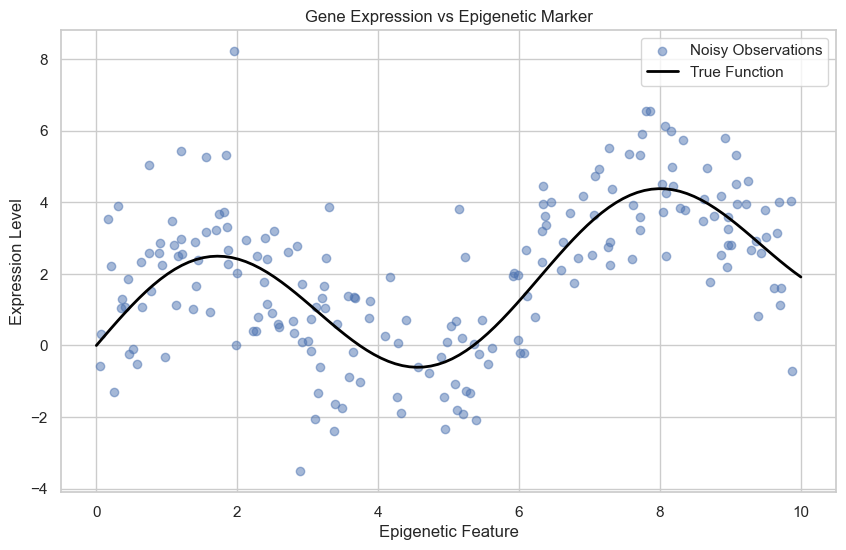

In [5]:
plt.figure(figsize=(10,6))
plt.scatter(X, y, label='Noisy Observations', alpha=0.5)
x_plot = np.linspace(0, 10, 100).reshape(-1, 1)
plt.plot(x_plot, true_function(x_plot), color='black', label='True Function', linewidth=2)
plt.title('Gene Expression vs Epigenetic Marker')
plt.xlabel('Epigenetic Feature')
plt.ylabel('Expression Level')
plt.legend()
plt.show()

## Polynomial Regression Models
We compare models of varying complexity to visualize underfitting and overfitting.

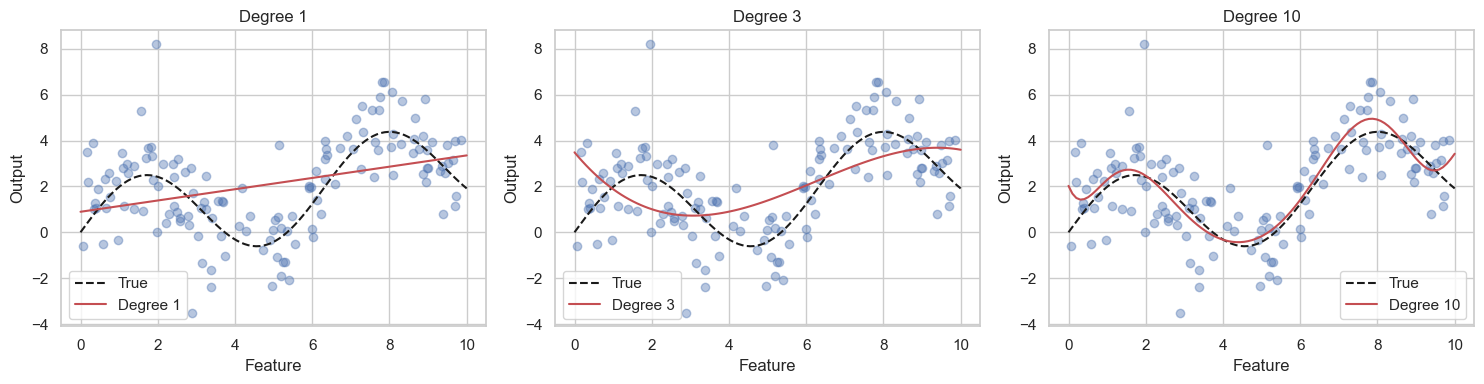

In [8]:
degrees = [1, 3, 10]
plt.figure(figsize=(15,4))
for i, d in enumerate(degrees):
    poly = PolynomialFeatures(d)
    model = LinearRegression().fit(poly.fit_transform(X_train), y_train)
    y_pred = model.predict(poly.transform(x_plot))

    plt.subplot(1, 3, i+1)
    plt.scatter(X_train, y_train, alpha=0.4)
    plt.plot(x_plot, true_function(x_plot), 'k--', label='True')
    plt.plot(x_plot, y_pred, 'r-', label=f'Degree {d}')
    plt.title(f'Degree {d}')
    plt.xlabel('Feature')
    plt.ylabel('Output')
    plt.legend()
plt.tight_layout()
plt.show()

## MSE vs Model Complexity
Track training vs test error as model complexity increases.

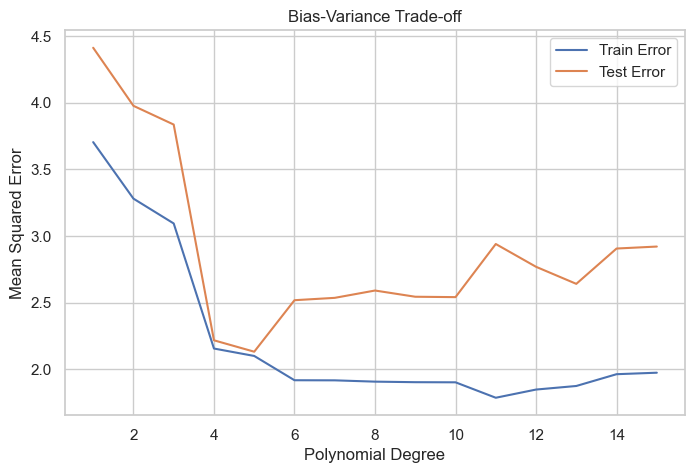

In [11]:
train_error, test_error = [], []
degrees = range(1, 16)
for d in degrees:
    poly = PolynomialFeatures(d)
    X_poly_train = poly.fit_transform(X_train)
    X_poly_test = poly.transform(X_test)
    model = LinearRegression().fit(X_poly_train, y_train)
    train_error.append(mean_squared_error(y_train, model.predict(X_poly_train)))
    test_error.append(mean_squared_error(y_test, model.predict(X_poly_test)))

plt.figure(figsize=(8,5))
plt.plot(degrees, train_error, label='Train Error')
plt.plot(degrees, test_error, label='Test Error')
plt.xlabel('Polynomial Degree')
plt.ylabel('Mean Squared Error')
plt.title('Bias-Variance Trade-off')
plt.legend()
plt.show()

## Regularization: Ridge vs Lasso
See how these methods help reduce overfitting in high-complexity models.

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=1.23983e-20): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.598e+02, tolerance: 5.920e-02
  model = cd_fast.enet_coordinate_descent(


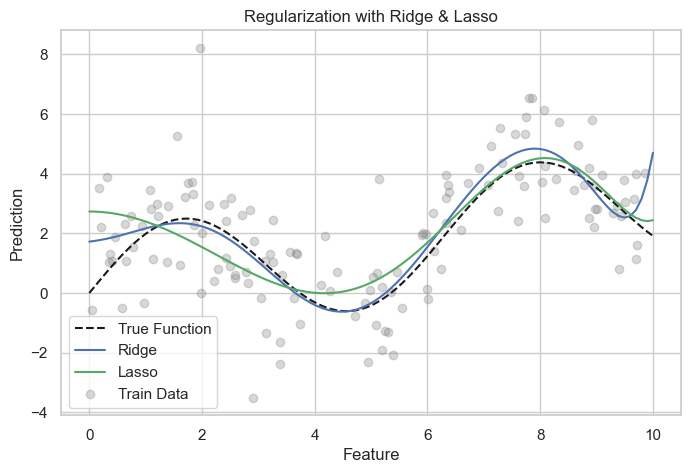

In [16]:
poly = PolynomialFeatures(10)
X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)
ridge = Ridge(alpha=10).fit(X_poly_train, y_train)
lasso = Lasso(alpha=0.1, max_iter=10000).fit(X_poly_train, y_train)
import warnings
warnings.filterwarnings('ignore')

plt.figure(figsize=(8,5))
plt.plot(x_plot, true_function(x_plot), 'k--', label='True Function')
plt.plot(x_plot, ridge.predict(poly.transform(x_plot)), 'b-', label='Ridge')
plt.plot(x_plot, lasso.predict(poly.transform(x_plot)), 'g-', label='Lasso')
plt.scatter(X_train, y_train, alpha=0.3, color='gray', label='Train Data')
plt.title('Regularization with Ridge & Lasso')
plt.xlabel('Feature')
plt.ylabel('Prediction')
plt.legend()
plt.show()